# 单条光谱离线处理过程展示

这个 notebook 对照当前 `dataset_process` 的真实实现，展示单条光谱在离线阶段的处理顺序：

1. 读取原始光谱
2. 使用 AsLS 做基线校正（拟合时跳过 `bad_bands`）
3. 按配置裁剪波段
4. 插值到统一波数坐标
5. 删除 `bad_bands` 区间
6. 用库函数 `preprocess_single_spectrum` 复核结果
7. 展示绘图默认使用的 `SNV` 归一化

注意：`dataset_process preprocess-train` 和 `preprocess-test` 落盘保存的是删除坏波段后的光谱，
不是 SNV 后的结果；SNV 主要用于均值图展示，默认由 `DEFAULT_PIPELINE_CONFIG.norm_method` 控制。


In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Microsoft YaHei'
import numpy as np
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from dataset_process.cli import ensure_dataset_layout
from dataset_process.common import (
    asls_baseline,
    build_valid_mask,
    minmax_normalize,
    preprocess_single_spectrum,
    read_arc_data,
    snv,
)
from dataset_process.pipeline import DEFAULT_PIPELINE_CONFIG
from dataset_process.profiles import get_profile

sns.set_theme(style="whitegrid", context="talk", font="Microsoft YaHei")
plt.rcParams["figure.figsize"] = (10, 5)

DATASET_NAME = "bacteria"
profile = get_profile(DATASET_NAME)  # 也可改成中文别名，例如 "细菌"
dataset_dir = ensure_dataset_layout(profile)
cfg = DEFAULT_PIPELINE_CONFIG
BAD_BANDS = profile.train_bad_bands
WN_REF = cfg.build_wn_ref()


def pick_sample_path(dataset_dir, profile):
    """优先选 dataset_raw 中的样本；如果没有，再回退到其他目录。"""
    candidate_roots = [
        dataset_dir / profile.root_process_raw,
        dataset_dir / profile.root_init,
        dataset_dir / profile.root_train_clean,
        dataset_dir / profile.root_test_raw,
        dataset_dir / profile.root_test_clean,
    ]
    for root in candidate_roots:
        if not root.is_dir():
            continue
        matches = sorted(root.rglob("*.arc_data"))
        if matches:
            return matches[0]
    raise FileNotFoundError("未找到可展示的 .arc_data 文件，请先准备 dataset_raw 或 dataset_init")


def add_bad_band_spans(ax, bad_bands, label="bad bands"):
    for i, (band_min, band_max) in enumerate(bad_bands):
        ax.axvspan(
            band_min,
            band_max,
            color="gray",
            alpha=0.15,
            label=label if i == 0 else None,
        )


sample_path = pick_sample_path(dataset_dir, profile)
print(f"dataset_dir = {dataset_dir}")
print(f"sample_path = {sample_path}")
print(f"cut range = [{cfg.cut_min}, {cfg.cut_max}]")
print(f"target_points = {cfg.target_points}")
print(f"bad_bands = {BAD_BANDS}")


dataset_dir = E:\Pythonproject\拉曼光谱分类\dataset\细菌
sample_path = E:\Pythonproject\拉曼光谱分类\dataset\细菌\dataset_raw\Citrobacter\CITF\CITF01_cell10_Area01_000_shift_cos.arc_data
cut range = [600, 1800]
target_points = 896
bad_bands = ((900.0, 950.0),)


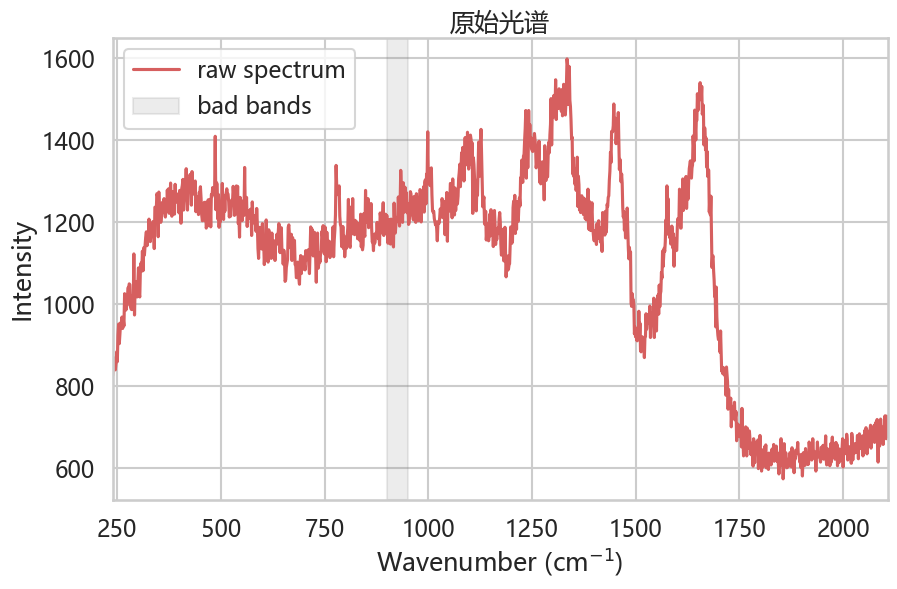

原始点数: 1340
原始波数范围: 239.17 -> 2107.62


In [8]:
# 1. 读取原始光谱
wn, sp = read_arc_data(sample_path)
if wn.size == 0 or sp.size == 0:
    raise ValueError(f"读取失败：{sample_path}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wn, sp, color=sns.color_palette("muted")[3], label="raw spectrum")
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([wn.min(), wn.max()])
ax.set_title("原始光谱")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()

print(f"原始点数: {wn.size}")
print(f"原始波数范围: {wn.min():.2f} -> {wn.max():.2f}")


C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarning: Glyph 26657 (\N{CJK UNIFIED IDEOGRAPH-6821}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fallinty\AppData\Local\Temp\ipykernel_34024\2053393822.py:24: UserWarni

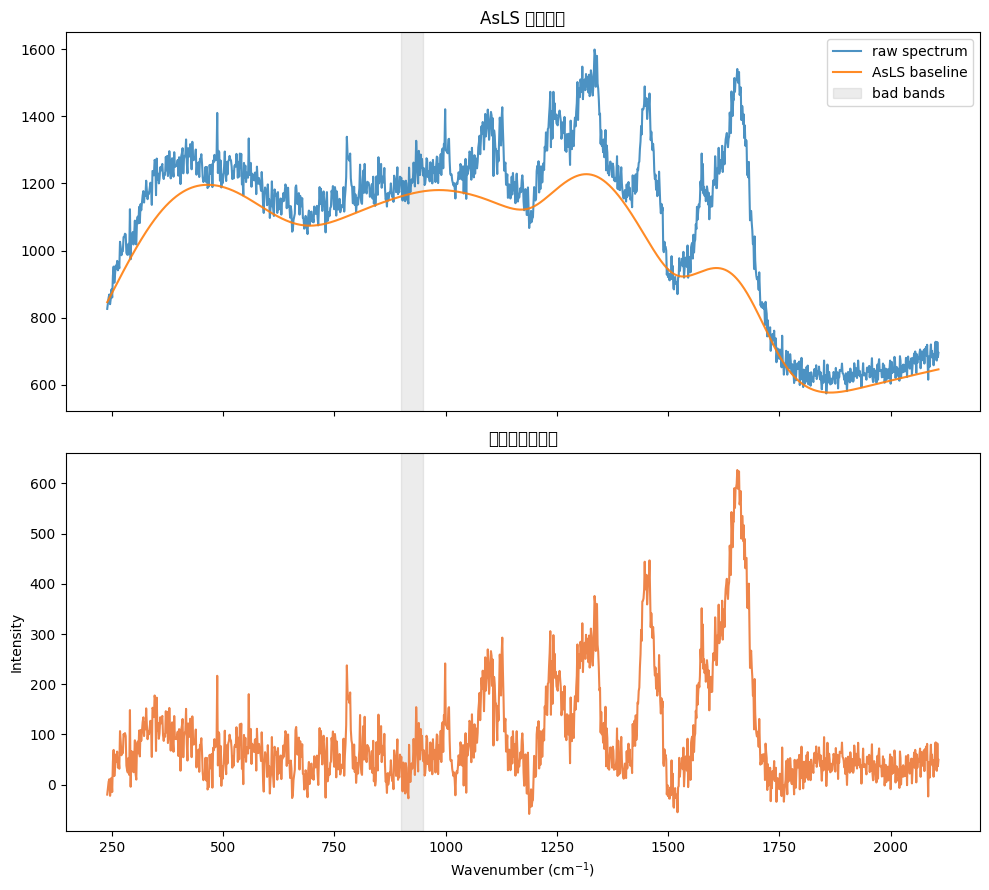

In [4]:
# 2. AsLS 基线校正：拟合时跳过坏波段
valid_mask_raw = build_valid_mask(wn, BAD_BANDS)
baseline = asls_baseline(
    sp,
    lam=cfg.asls_lam,
    p=cfg.asls_p,
    niter=cfg.asls_max_iter,
    valid_mask=valid_mask_raw,
)
sp_bc = sp - baseline

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(wn, sp, label="raw spectrum", alpha=0.8)
axes[0].plot(wn, baseline, label="AsLS baseline", alpha=0.9)
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_title("AsLS 基线估计")
axes[0].legend()

axes[1].plot(wn, sp_bc, color=sns.color_palette("muted")[1])
add_bad_band_spans(axes[1], BAD_BANDS)
axes[1].set_title("基线校正后光谱")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()


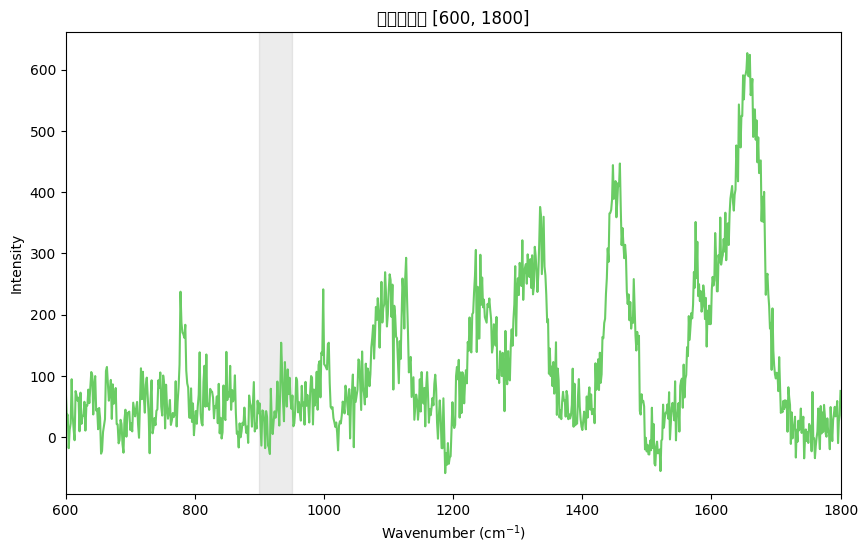

裁剪后点数: 861
裁剪后波数范围: 600.16 -> 1799.78


In [9]:
# 3. 按当前配置裁剪波段
mask_cut = (wn >= cfg.cut_min) & (wn <= cfg.cut_max)
wn_cut = wn[mask_cut]
sp_cut = sp_bc[mask_cut]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wn_cut, sp_cut, color=sns.color_palette("muted")[2])
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([cfg.cut_min, cfg.cut_max])
ax.set_title(f"裁剪后光谱 [{cfg.cut_min}, {cfg.cut_max}]")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"裁剪后点数: {wn_cut.size}")
print(f"裁剪后波数范围: {wn_cut[0]:.2f} -> {wn_cut[-1]:.2f}")


In [ ]:
# 4. 插值到统一波数坐标
wn_uniform = WN_REF.copy()
sp_interp = np.interp(wn_uniform, wn_cut, sp_cut)

fig, ax = plt.subplots()
ax.plot(wn_uniform, sp_interp, color=sns.color_palette("muted")[0])
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([cfg.cut_min, cfg.cut_max])
ax.set_title(f"插值后光谱 ({cfg.target_points} points)")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"插值后点数: {sp_interp.shape[0]}")


In [ ]:
# 5. 按 bad_bands 删除坏波段
# 当前 dataset_process 的真实做法是直接删除对应区间，不再做填零、线性补点或 NaN 掩码落盘。
keep_mask = build_valid_mask(wn_uniform, BAD_BANDS)
if keep_mask is None:
    keep_mask = np.ones_like(wn_uniform, dtype=bool)

wn_processed = wn_uniform[keep_mask]
sp_processed = sp_interp[keep_mask]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=False)
axes[0].plot(wn_uniform, sp_interp, color=sns.color_palette("muted")[0])
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_xlim([cfg.cut_min, cfg.cut_max])
axes[0].set_title("删除坏波段之前")

axes[1].plot(wn_processed, sp_processed, color=sns.color_palette("muted")[4])
axes[1].set_xlim([wn_processed.min(), wn_processed.max()])
axes[1].set_title("删除坏波段之后（离线落盘结果）")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()

print(f"删除坏波段后点数: {sp_processed.shape[0]}")
print(f"删除点数: {(~keep_mask).sum()}")


In [ ]:
# 6. 直接调用库函数复核：应与上面的手工拆解结果一致
wn_pkg, sp_pkg = preprocess_single_spectrum(
    wn,
    sp,
    cut_min=cfg.cut_min,
    cut_max=cfg.cut_max,
    wn_ref=WN_REF,
    bad_bands=BAD_BANDS,
    asls_lam=cfg.asls_lam,
    asls_p=cfg.asls_p,
    asls_max_iter=cfg.asls_max_iter,
)

if wn_pkg is None or sp_pkg is None:
    raise RuntimeError("preprocess_single_spectrum 返回空结果，通常是裁剪后有效点数不足")

print(f"wn 一致: {np.array_equal(wn_processed, wn_pkg)}")
print(f"sp 最大绝对误差: {np.max(np.abs(sp_processed - sp_pkg)):.6e}")

fig, ax = plt.subplots()
ax.plot(wn_pkg, sp_pkg, color=sns.color_palette("muted")[5], label="package output")
ax.set_xlim([wn_pkg.min(), wn_pkg.max()])
ax.set_title("preprocess_single_spectrum 输出")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()


In [ ]:
# 7. SNV 归一化：这是当前绘图默认使用的归一化方式，不是离线落盘内容
sp_snv = snv(sp_pkg)
sp_minmax = minmax_normalize(sp_pkg)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].plot(wn_pkg, sp_snv, color=sns.color_palette("muted")[6])
axes[0].set_title("SNV 归一化后光谱（当前均值图默认）")
axes[0].set_ylabel("SNV intensity")

axes[1].plot(wn_pkg, sp_minmax, color=sns.color_palette("muted")[7])
axes[1].set_title("Min-Max 归一化后光谱（可选绘图方式）")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Min-Max intensity")
plt.tight_layout()
plt.show()

print("当前离线真实流程：原始光谱 -> AsLS -> 裁剪 -> 插值 -> 删除 bad_bands -> 写入 dataset_train / dataset_test")
print(f"当前 DEFAULT_PIPELINE_CONFIG.norm_method = {cfg.norm_method!r}")
